# Bootstrap Tail Overestimation Test

**Hypothesis:** The multinomial logistic regression overestimates tail category
probabilities (P(7), P(8), P(9+)), and these errors compound when aggregating
to bet-level probabilities like P(3+).

**Test:** Bootstrap resample the training data, refit the model N times, and compare
the bootstrap-averaged predictions against point estimates and actual outcomes.

**Success criteria (define BEFORE running):**
- Tail categories show higher coefficient of variation across bootstrap iterations
- Bootstrap-averaged aggregated probabilities have lower Brier scores than point estimates
- Overconfidence on extreme predictions is reduced

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import sqlite3
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
from nba import NBAbase, NBAetl, NBAdata, NBAmodels
from nba.run import run_pipeline,data_pull,run_model

etl = NBAetl.etl()
data = NBAdata.data()
from betting import funcs
od = funcs.odds()


In [4]:
# =============================================================
# CONFIG — UPDATE THESE
# =============================================================

N_BOOTSTRAPS = 200
RANDOM_SEED = 42
TEST_SIZE = 0.2

# UPDATE: your feature columns
FEATURE_COLS = [
    'cornerRatio',
 'abv_interaction',
 'crn_interaction',
 'mvAvgThrees',
 'daysBetweenGames',
 'wide_interaction',
 'home',
 'crn_fgaMv',
 'abv_fgaMv',
 'threes_residualsAllowedMv',
 'past3ThrPtPrct',
 'mvGood3Rate'
]

TARGET_COL = 'threesMade'


In [98]:
# =============================================================
# LOAD DATA — UPDATE CONNECTION AND QUERY
# =============================================================
from nba import NBAbase, NBAetl, NBAdata, NBAmodels
etl = NBAetl.etl()
data = NBAdata.data()
threes = NBAmodels.models('threes')

td = data.threes_pipe(threes.data)

td = data.clean_na(td)

train = td[td.game_date.between('2022-10-01','2025-04-12')].filter(threes.features+['threesMade','name','game_date'])
train.dropna(inplace=True)

test = td[td.game_date.between('2025-10-01','2026-04-11')].filter(threes.features+['threesMade','name','game_date'])
test.dropna(inplace=True)


In [8]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
# =============================================================
# TRAIN/TEST SPLIT AND POINT ESTIMATE MODEL
# =============================================================

y_train = train.threesMade
y_test = test.threesMade

x_train = train.filter(threes.features)
x_test = test.filter(threes.features)

x_train_scaled = threes.standRobust_scaler(x_train)
x_test_scaled = threes.standRobust_scaler(x_test)


x_train_rescaled = pd.DataFrame(data = ss.fit_transform(x_train),columns = x_train.columns.values)
x_test_rescaled = pd.DataFrame(data = ss.transform(x_test),columns = x_test.columns.values)

x_train_rescaled['home'] = x_train.home.values
x_train_rescaled['cornerRatio'] = x_train.cornerRatio.values
x_test_rescaled['home'] = x_test.home.values
x_test_rescaled['cornerRatio']= x_test.cornerRatio.values

print('Train: {:,}, Test: {:,}'.format(len(x_train), len(x_test)))

Train: 68,482, Test: 23,173


In [11]:
# fit point estimate model

three_probs = threes.model.predict(x_test_sm)



NameError: name 'x_test_sm' is not defined

## Bootstrap Function

In [8]:
def fit_bootstrap_model(X_train_sm, y_train, X_test_sm):
    """
    Single bootstrap iteration: resample training data,
    fit MNLogit, return predicted probabilities and classes.
    """
    n = len(X_train_sm)
    idx = np.random.choice(n, size=n, replace=True)
    
    X_boot = X_train_sm.iloc[idx].reset_index(drop=True)
    y_boot = y_train.iloc[idx].reset_index(drop=True)
    
    model = sm.MNLogit(y_boot, X_boot)
    results = model.fit(disp=0, maxiter=200)
    
    probs = results.predict(X_test_sm)
    classes = np.array(sorted(y_boot.unique()))
    
    return probs, classes

In [75]:
probs_full = threes.model.predict(x_test_sm)
np.random.seed(521)
n_boots = 10_000
boot_agg_store = {t: np.zeros((n_boots, n_test)) for t in AGGREGATION_THRESHOLDS}

for i in range(n_boots):
    idx = np.random.choice(n_test, size=n_test, replace=True)
    boot_probs = point_prob_arr[idx]
    for t in AGGREGATION_THRESHOLDS:
        mask = point_classes >= t
        boot_agg_store[t][i] = boot_probs[:, mask].sum(axis=1)

    if (i + 1) % 1000 == 0:
        print('Completed {}/{}'.format(i + 1, n_boots))

Completed 1000/10000
Completed 2000/10000
Completed 3000/10000
Completed 4000/10000
Completed 5000/10000
Completed 6000/10000
Completed 7000/10000
Completed 8000/10000
Completed 9000/10000
Completed 10000/10000


## Bootstrap Results Analysis

### Test 1: Category Drop Rate
How often does the bootstrap lose a category entirely? High drop rate = not enough data to support that category.

In [10]:
point_classes = [0,1,2,3,4,5,6,7,8,9]
missing = Counter()
for classes in all_classes:
    unique_classes = set(classes)
    for c in point_classes:
        if c not in unique_classes:
            missing[c] += 1
            
n_success = len(all_classes)

print('Category Drop Rate Across {} Bootstrap Iterations'.format(n_success))
print('=' * 50)
for c in sorted(point_classes):
    ct = missing.get(c, 0)
    print('Category {:>3}: dropped {} times ({:.1f}%)'.format(
        c, ct, ct / n_success * 100))

# flag categories for potential collapse
collapse_threshold = 0.05
flagged = [c for c in point_classes if missing.get(c, 0) / n_success > collapse_threshold]
if flagged:
    print('\n>> Categories to consider collapsing (>{:.0f}% drop rate): {}'.format(
        collapse_threshold * 100, flagged))
else:
    print('\n>> All categories stable across bootstrap iterations')

Category Drop Rate Across 10000 Bootstrap Iterations
Category   0: dropped 0 times (0.0%)
Category   1: dropped 0 times (0.0%)
Category   2: dropped 0 times (0.0%)
Category   3: dropped 0 times (0.0%)
Category   4: dropped 0 times (0.0%)
Category   5: dropped 0 times (0.0%)
Category   6: dropped 0 times (0.0%)
Category   7: dropped 0 times (0.0%)
Category   8: dropped 0 times (0.0%)
Category   9: dropped 0 times (0.0%)

>> All categories stable across bootstrap iterations


### Test 2: Per-Category Uncertainty
Coefficient of variation for each outcome category. Tail categories should show higher CoV.

In [77]:
point_prob_arr = probs_full.values if hasattr(probs_full, 'values') else probs_full
n_test = len(point_prob_arr)
point_classes = np.array(probs_full.columns)
AGGREGATION_THRESHOLDS = [2, 3, 4, 5,6,7,8,9]

# Test 2 computed directly from probs_full - no bootstrap needed for fixed model
category_stats = []
for j, c in enumerate(point_classes):
    mean_prob = point_prob_arr[:, j].mean()
    std_prob = point_prob_arr[:, j].std()
    cov = std_prob / mean_prob if mean_prob > 1e-6 else np.inf
    category_stats.append({'category': c, 'mean_prob': mean_prob, 'boot_std': std_prob, 'cov': cov})

cat_df = pd.DataFrame(category_stats)
print(cat_df.to_string(index=False))

# store only aggregated probs per threshold across bootstrap iterations
np.random.seed(521)
n_boots = 10_000
boot_agg_store = {t: np.zeros((n_boots, n_test)) for t in AGGREGATION_THRESHOLDS}

for i in range(n_boots):
    idx = np.random.choice(n_test, size=n_test, replace=True)
    boot_probs = point_prob_arr[idx]
    for t in AGGREGATION_THRESHOLDS:
        mask = point_classes >= t
        boot_agg_store[t][i] = boot_probs[:, mask].sum(axis=1)

    if (i + 1) % 1000 == 0:
        print('Completed {}/{}'.format(i + 1, n_boots))

 category  mean_prob  boot_std      cov
        0   0.397830  0.267816 0.673193
        1   0.239526  0.077920 0.325311
        2   0.162407  0.076776 0.472739
        3   0.100879  0.074632 0.739822
        4   0.051382  0.051177 0.996004
        5   0.027299  0.037031 1.356505
        6   0.011491  0.018558 1.614982
        7   0.006259  0.011825 1.889261
        8   0.001987  0.004528 2.278455
        9   0.000940  0.003151 3.350389
Completed 1000/10000
Completed 2000/10000
Completed 3000/10000
Completed 4000/10000
Completed 5000/10000
Completed 6000/10000
Completed 7000/10000
Completed 8000/10000
Completed 9000/10000
Completed 10000/10000


In [16]:
# compute per-category stats
category_stats = []
for j, c in enumerate(point_classes):
    mean_prob = point_prob_arr[:, j].mean()
    std_prob = point_prob_arr[:, j].std()
    cov = std_prob / mean_prob if mean_prob > 1e-6 else np.inf
    category_stats.append({
        'category': c,
        'mean_prob': mean_prob,
        'boot_std': std_prob,
        'cov': cov
    })

cat_df = pd.DataFrame(category_stats)
print(cat_df.to_string(index=False))

 category  mean_prob  boot_std      cov
        0   0.397830  0.267816 0.673193
        1   0.239526  0.077920 0.325311
        2   0.162407  0.076776 0.472739
        3   0.100879  0.074632 0.739822
        4   0.051382  0.051177 0.996004
        5   0.027299  0.037031 1.356505
        6   0.011491  0.018558 1.614982
        7   0.006259  0.011825 1.889261
        8   0.001987  0.004528 2.278455
        9   0.000940  0.003151 3.350389


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


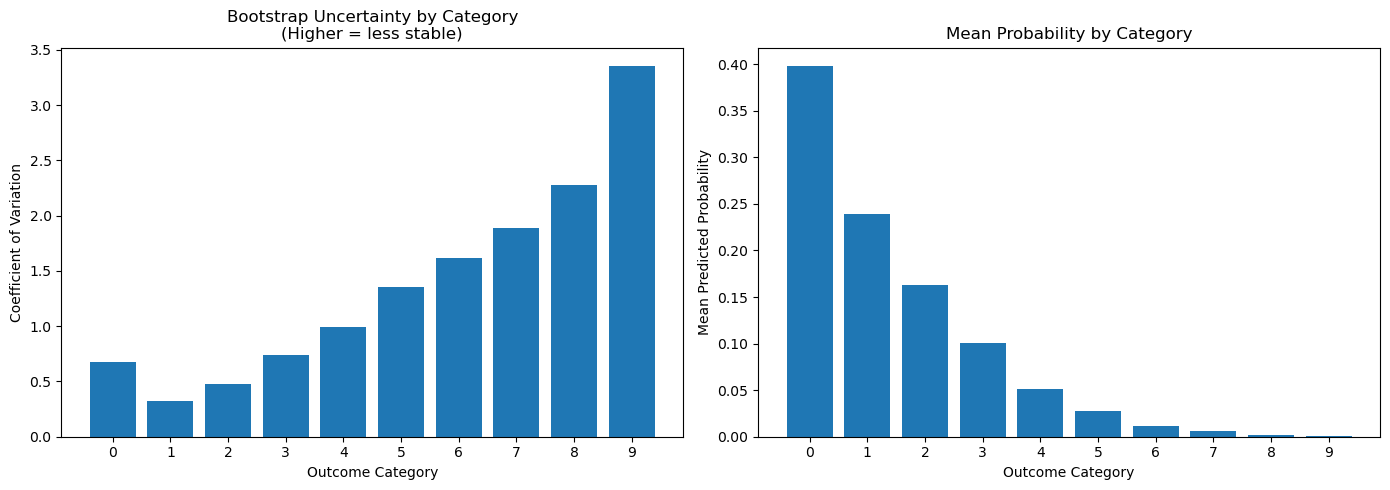

In [17]:
# plot: CoV by category
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cat_df['category'].astype(str), cat_df['cov'])
axes[0].set_xlabel('Outcome Category')
axes[0].set_ylabel('Coefficient of Variation')
axes[0].set_title('Bootstrap Uncertainty by Category\n(Higher = less stable)')

axes[1].bar(cat_df['category'].astype(str), cat_df['mean_prob'])
axes[1].set_xlabel('Outcome Category')
axes[1].set_ylabel('Mean Predicted Probability')
axes[1].set_title('Mean Probability by Category')

plt.tight_layout()
plt.show()

### Test 3: Aggregated Bet Probabilities — Point vs Bootstrap
Compare calibration at each betting threshold.

In [30]:
def readable_cov(model, top_n=100):
    se = np.sqrt(np.diag(model.cov_params()))
    params = model.params
    summary = []
    for i, name in enumerate(model.cov_params().columns):
        summary.append({
            'outcome': name[0],
            'parameter': name[1],
            'coefficient': params.values.flatten()[i],
            'std_error': se[i],
            'z_score': params.values.flatten()[i] / se[i]
        })
    df = pd.DataFrame(summary)
    df['abs_z'] = df.z_score.abs()
    return df

covdf = readable_cov(threes.model, top_n=1000)

In [206]:
test.threesMade.value_counts(normalize=True).sort_values().cumsum() * 100

threesMade
11      0.004262
12      0.008524
10      0.038360
9       0.110817
8       0.315404
7       0.814082
6       1.998977
5       4.556304
4       9.943739
3      20.087802
2      35.879294
1      59.615549
0     100.000000
Name: proportion, dtype: float64

---Retrain

In [315]:
import statsmodels.api as sm

In [384]:
threes.brier_scores([x if x<10 else 9 for x in y_test],threes.model.predict(sm.add_constant(x_test_scaled.filter(threes.features))))


brier score of:  0.665


0.6653604613296171

In [ ]:
readable_cov(up
             

In [385]:
preds = threes.model.predict(sm.add_constant(x_test.filter(threes.features))).mean()

In [386]:
actuals = pd.Series([x if x<10 else 9 for x in y_test]).value_counts(normalize=True).sort_index()

In [387]:
comps = pd.DataFrame({'actuals':actuals,'preds':preds})

In [401]:
comps['diff'] = comps.actuals - comps.preds
comps['cumulativeDiff'] = (comps.sort_index(ascending=False).cumsum().actuals - comps.sort_index(ascending=False).cumsum().preds).round(5).sort_index()

In [402]:
comps

,actuals,preds,diff,cumulativeDiff
0,0.399215,0.391683,0.007532,0.00000
1,0.245113,0.244660,0.000453,-0.00753
2,0.164157,0.165274,-0.001118,-0.00799
3,0.096233,0.101408,-0.005175,-0.00687
4,0.052604,0.050861,0.001743,-0.00169
5,0.025288,0.026547,-0.001259,-0.00344
6,0.010486,0.010922,-0.000436,-0.00218
7,0.004056,0.005958,-0.001901,-0.00174
8,0.001683,0.001845,-0.000162,0.00016
9,0.001165,0.000843,0.000322,0.00032


In [42]:
def brier_summary(probs, y, thresholds=[2,3,4,5]):
    """
    Brier score overall and by threshold.
    probs: DataFrame of predicted probabilities (n_obs x n_classes)
    y: Series of actual outcomes
    """
    point_classes = np.array(probs.columns)
    y_arr = y.values if hasattr(y, 'values') else y
    prob_arr = probs.values if hasattr(probs, 'values') else probs

    results = []
    for threshold in thresholds:
        mask = point_classes >= threshold
        pred_agg = prob_arr[:, mask].sum(axis=1)
        actual = (y_arr >= threshold).astype(float)
        brier = ((pred_agg - actual) ** 2).mean()
        results.append({
            'threshold': '{}+'.format(threshold),
            'actual_rate': actual.mean(),
            'pred_rate': pred_agg.mean(),
            'overconfidence': pred_agg.mean() - actual.mean(),
            'brier_score': brier
        })

    df_out = pd.DataFrame(results)
    print('Brier Score Summary')
    print('=' * 60)
    print(df_out.to_string(index=False))
    return df_out


def residual_bias(probs, y, df, threshold=3):
    """
    Checks for systematic bias in residuals by probability decile,
    month, and cornerRatio bucket.
    probs: DataFrame of predicted probabilities
    y: Series of actual outcomes
    df: full player DataFrame containing game_date and cornerRatio
    """
    point_classes = np.array(probs.columns)
    y_arr = y.values if hasattr(y, 'values') else y
    prob_arr = probs.values if hasattr(probs, 'values') else probs

    mask = point_classes >= threshold
    pred_agg = prob_arr[:, mask].sum(axis=1)
    actual = (y_arr >= threshold).astype(float)
    residuals = pred_agg - actual

    results = df[['game_date', 'cornerRatio']].copy().reset_index(drop=True)
    results['pred'] = pred_agg
    results['actual'] = actual
    results['residual'] = residuals
    results['prob_decile'] = pd.qcut(pred_agg, 10, labels=False, duplicates='drop')
    results['month'] = pd.to_datetime(results['game_date']).dt.month

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # by probability decile
    decile_bias = results.groupby('prob_decile')['residual'].mean()
    axes[0].bar(decile_bias.index, decile_bias.values)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_xlabel('Probability Decile')
    axes[0].set_ylabel('Mean Residual')
    axes[0].set_title('Residual Bias by Probability Decile\nP({}+)'.format(threshold))

    # by month
    month_bias = results.groupby('month')['residual'].mean()
    axes[1].bar(month_bias.index, month_bias.values)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Mean Residual')
    axes[1].set_title('Residual Bias by Month\nP({}+)'.format(threshold))

    # by cornerRatio bucket
    cr_bias = results.groupby('cornerRatio')['residual'].mean()
    axes[2].bar(range(len(cr_bias)), cr_bias.values)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_xticks(range(len(cr_bias)))
    axes[2].set_xticklabels(['{:.2f}'.format(x) for x in cr_bias.index], rotation=45)
    axes[2].set_xlabel('cornerRatio Bucket')
    axes[2].set_ylabel('Mean Residual')
    axes[2].set_title('Residual Bias by cornerRatio\nP({}+)'.format(threshold))

    plt.tight_layout()
    plt.show()
    return results


def feature_describe(df, feature_cols, target_col='threesMade'):
    """
    Describe statistics for each feature grouped by outcome class.
    """
    for col in feature_cols:
        print('\n{}'.format(col))
        print('-' * 60)
        print(df.groupby(target_col)[col].describe().round(4).to_string())


def feature_distributions(df, feature_cols, target_col='threesMade'):
    """
    Distribution plots for each feature, overlaid by outcome class.
    """
    classes = sorted(df[target_col].unique())
    n_cols = len(feature_cols)
    n_rows = -(-len(feature_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        for cls in classes:
            subset = df[df[target_col] == cls][col].dropna()
            axes[i].hist(subset, bins=30, alpha=0.3, label='class {}'.format(cls), density=True)
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right')
    plt.suptitle('Feature Distributions by Outcome Class', y=1.01)
    plt.tight_layout()
    plt.show()


def feature_boxplots(df, feature_cols, target_col='threesMade',bin=None):
    """
    Boxplots of mean feature value aggregated by outcome class.
    """
    df.threesMade = df.threesMade.astype(int) if bin==None else [int(x) if x<bin else bin for x in df.threesMade]
    agg = df.groupby(target_col)[feature_cols].mean()
    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        axes[i].bar(agg.index.astype(str), agg[col].values)
        axes[i].set_title(col)
        axes[i].set_xlabel('threesMade')
        axes[i].set_ylabel('Mean {}'.format(col))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Mean Feature Value by Outcome Class', y=1.01)
    plt.tight_layout()
    axes[i].set_xticks(range(len(agg.index)))
    axes[i].set_xticklabels(agg.index.astype(str), rotation=45, fontsize=8)
    plt.show()


def feature_joint(df, feature_cols, target_col='threesMade'):
    """
    Aggregated joint plots: mean feature vs mean outcome per cornerRatio bucket.
    """
    n_cols = 4
    n_rows = -(-len(feature_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    agg = df.groupby('cornerRatio').agg(
        mean_outcome=(target_col, 'mean'),
        **{'mean_{}'.format(col): (col, 'mean') for col in feature_cols}
    ).reset_index()

    for i, col in enumerate(feature_cols):
        axes[i].scatter(agg['mean_{}'.format(col)], agg['mean_outcome'], alpha=0.7)
        axes[i].set_xlabel('Mean {}'.format(col))
        axes[i].set_ylabel('Mean {}'.format(target_col))
        axes[i].set_title('{} vs {}'.format(col, target_col))

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Aggregated Joint: Mean Feature vs Mean Outcome by cornerRatio Bucket', y=1.01)
    plt.tight_layout()
    plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

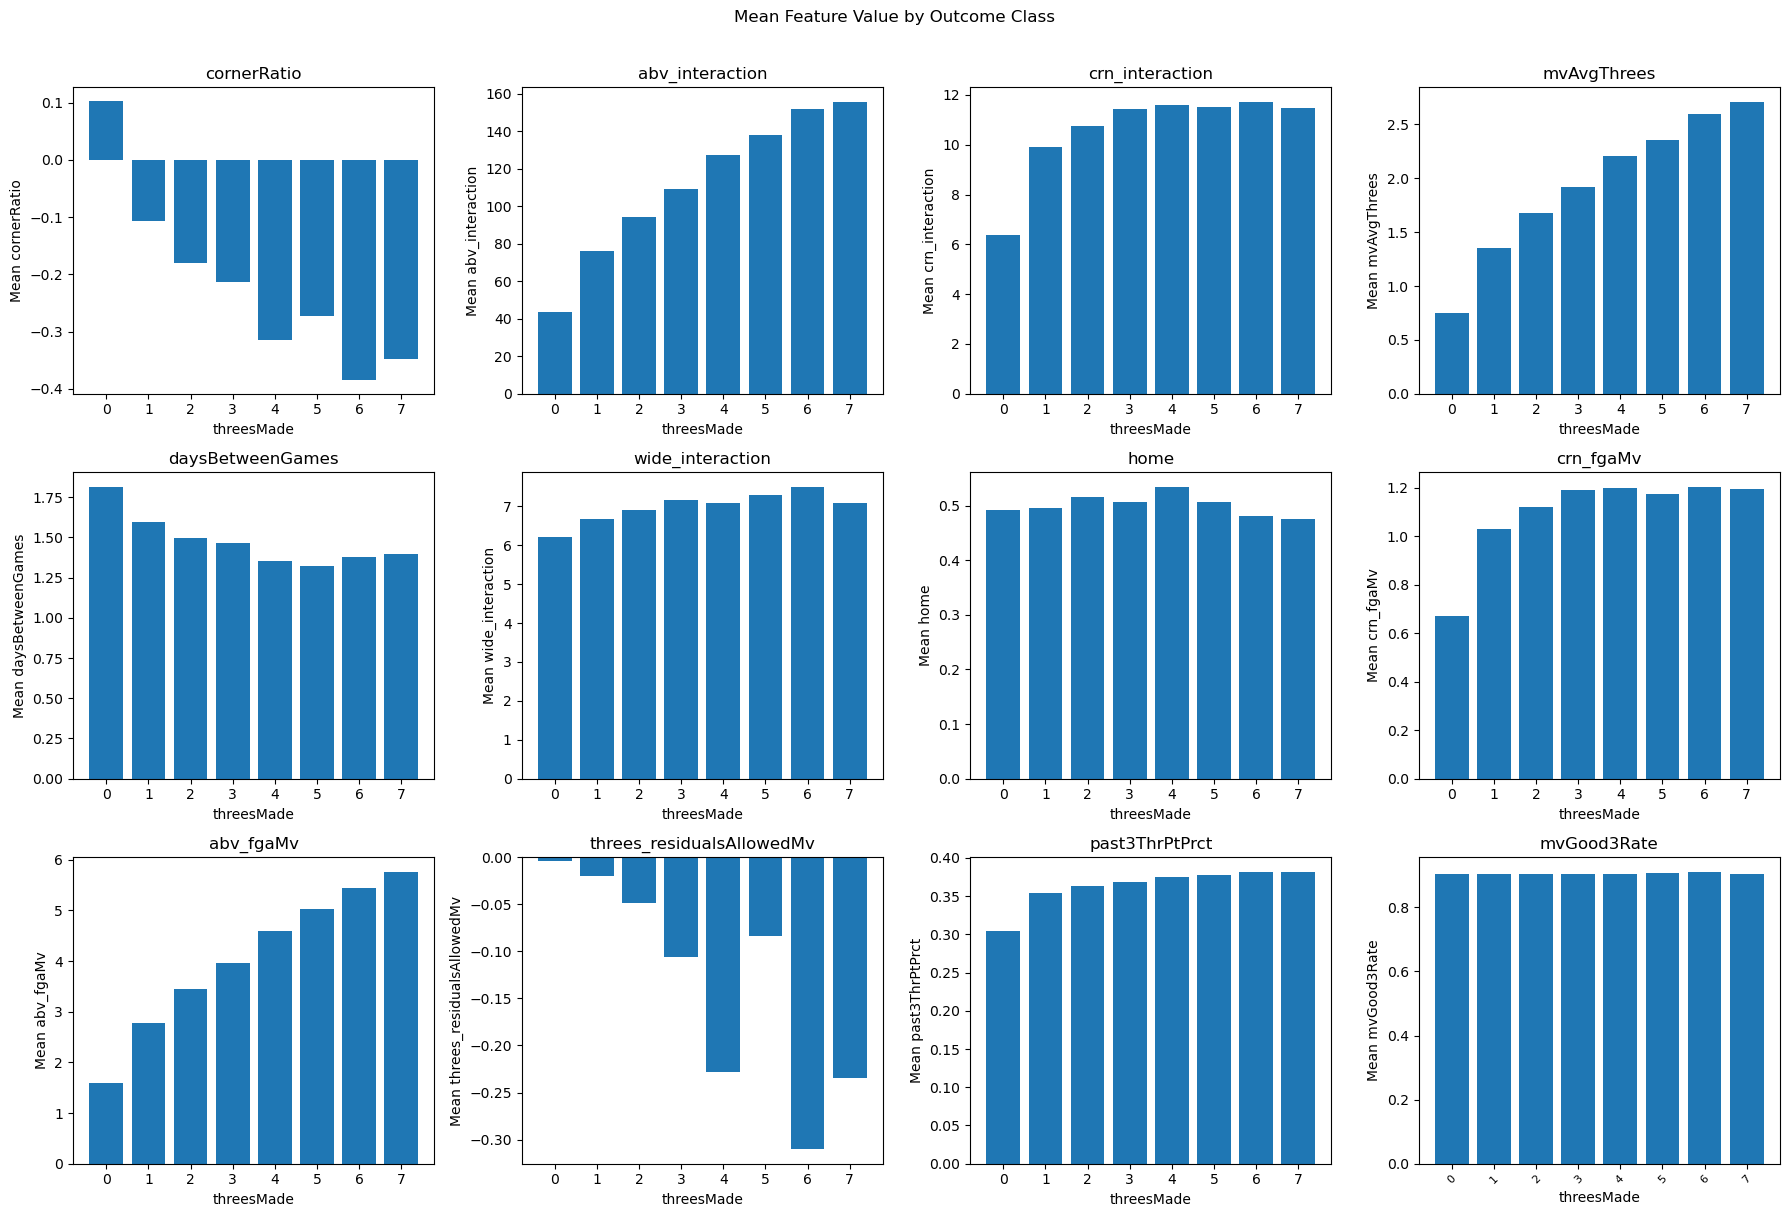

In [487]:
feature_boxplots(test.filter(threes.features[1:]+['threesMade']),threes.features[1:],bin=7)

In [421]:
y7cap = [x if x < 7 else 7 for x in y_train ]

In [27]:
newMod = sm.MNLogit(endog = np.array(y_train.clip(0,7)), exog = sm.add_constant(x_train_rescaled.filter(threes.features),))
upModel = newMod.fit(method = 'bfgs',maxiter=1000)
p = upModel.predict(sm.add_constant(x_test_rescaled.filter(threes.features)))

Optimization terminated successfully.
         Current function value: 1.344428
         Iterations: 321
         Function evaluations: 322
         Gradient evaluations: 322


In [28]:
threes.brier_scores(y_test.clip(0,7),p)

brier score of:  0.655


np.float64(0.6545668113823832)

In [31]:
readable_cov(upModel)[readable_cov(upModel).outcome=='7']

,outcome,parameter,coefficient,std_error,z_score,abs_z
78,7,const,0.145494,0.111184,1.308584,1.308584
79,7,cornerRatio,0.175803,0.137018,1.283062,1.283062
80,7,abv_interaction,0.193390,0.221736,0.872165,0.872165
81,7,crn_interaction,0.212552,0.166157,1.279225,1.279225
82,7,mvAvgThrees,0.308143,0.078534,3.923690,3.923690
83,7,daysBetweenGames,0.458384,0.063055,7.269648,7.269648
84,7,wide_interaction,-0.006838,0.089672,-0.076260,0.076260
85,7,home,0.001491,0.088571,0.016832,0.016832
86,7,crn_fgaMv,-0.007258,0.173772,-0.041769,0.041769
87,7,abv_fgaMv,0.029458,0.240588,0.122442,0.122442


<Axes: >

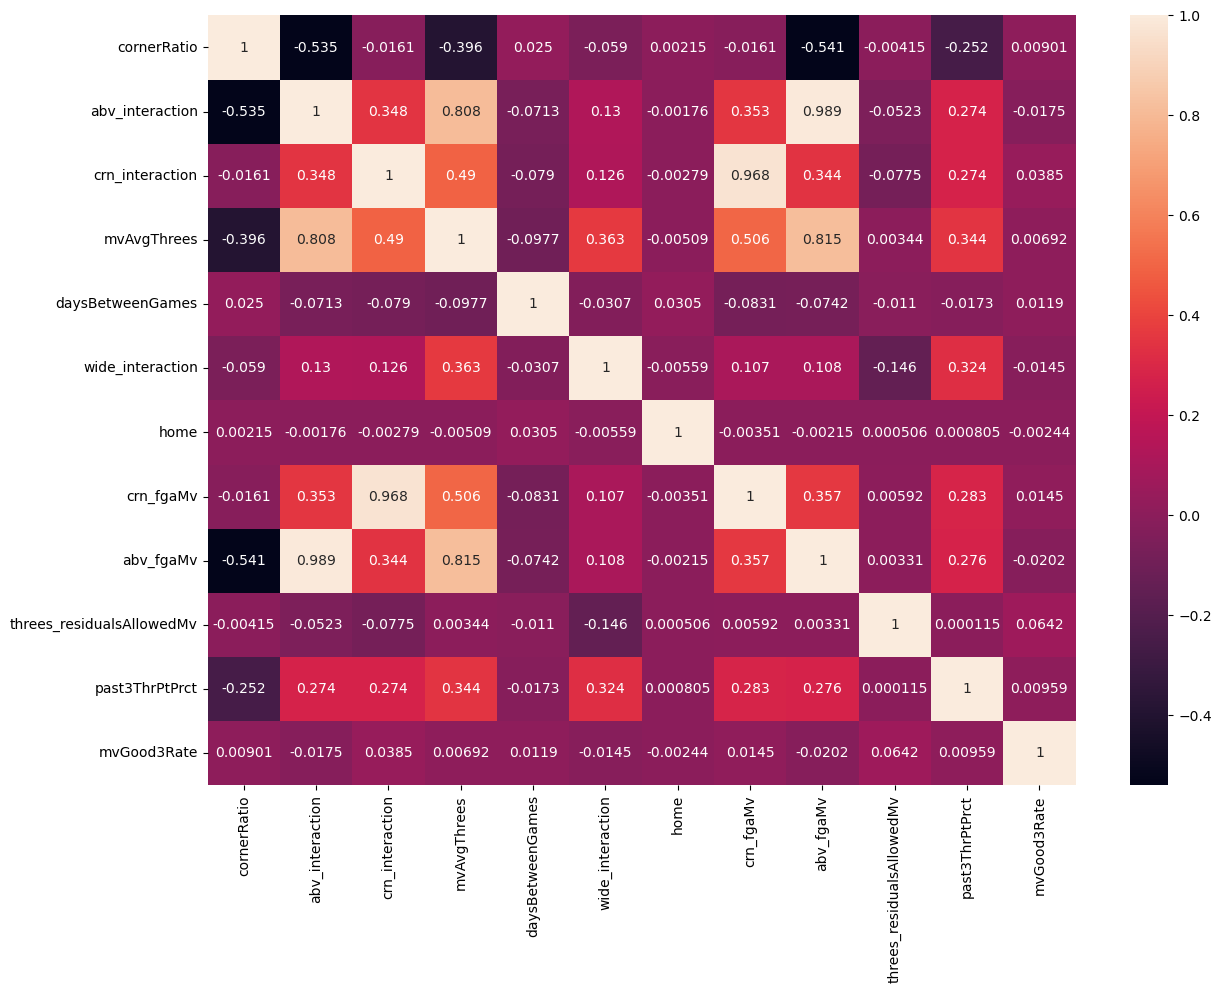

In [40]:
import seaborn as sns
plt.figure(figsize=(14,10))
sns.heatmap(x_train_rescaled.corr(),annot=True,fmt='.3g')

<Axes: >

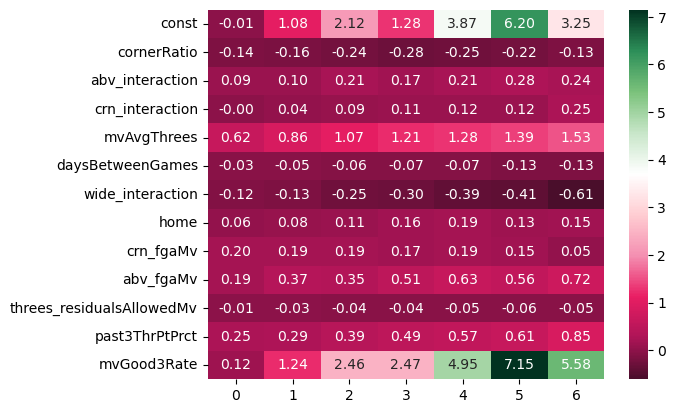

In [516]:
sns.heatmap(upModel.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

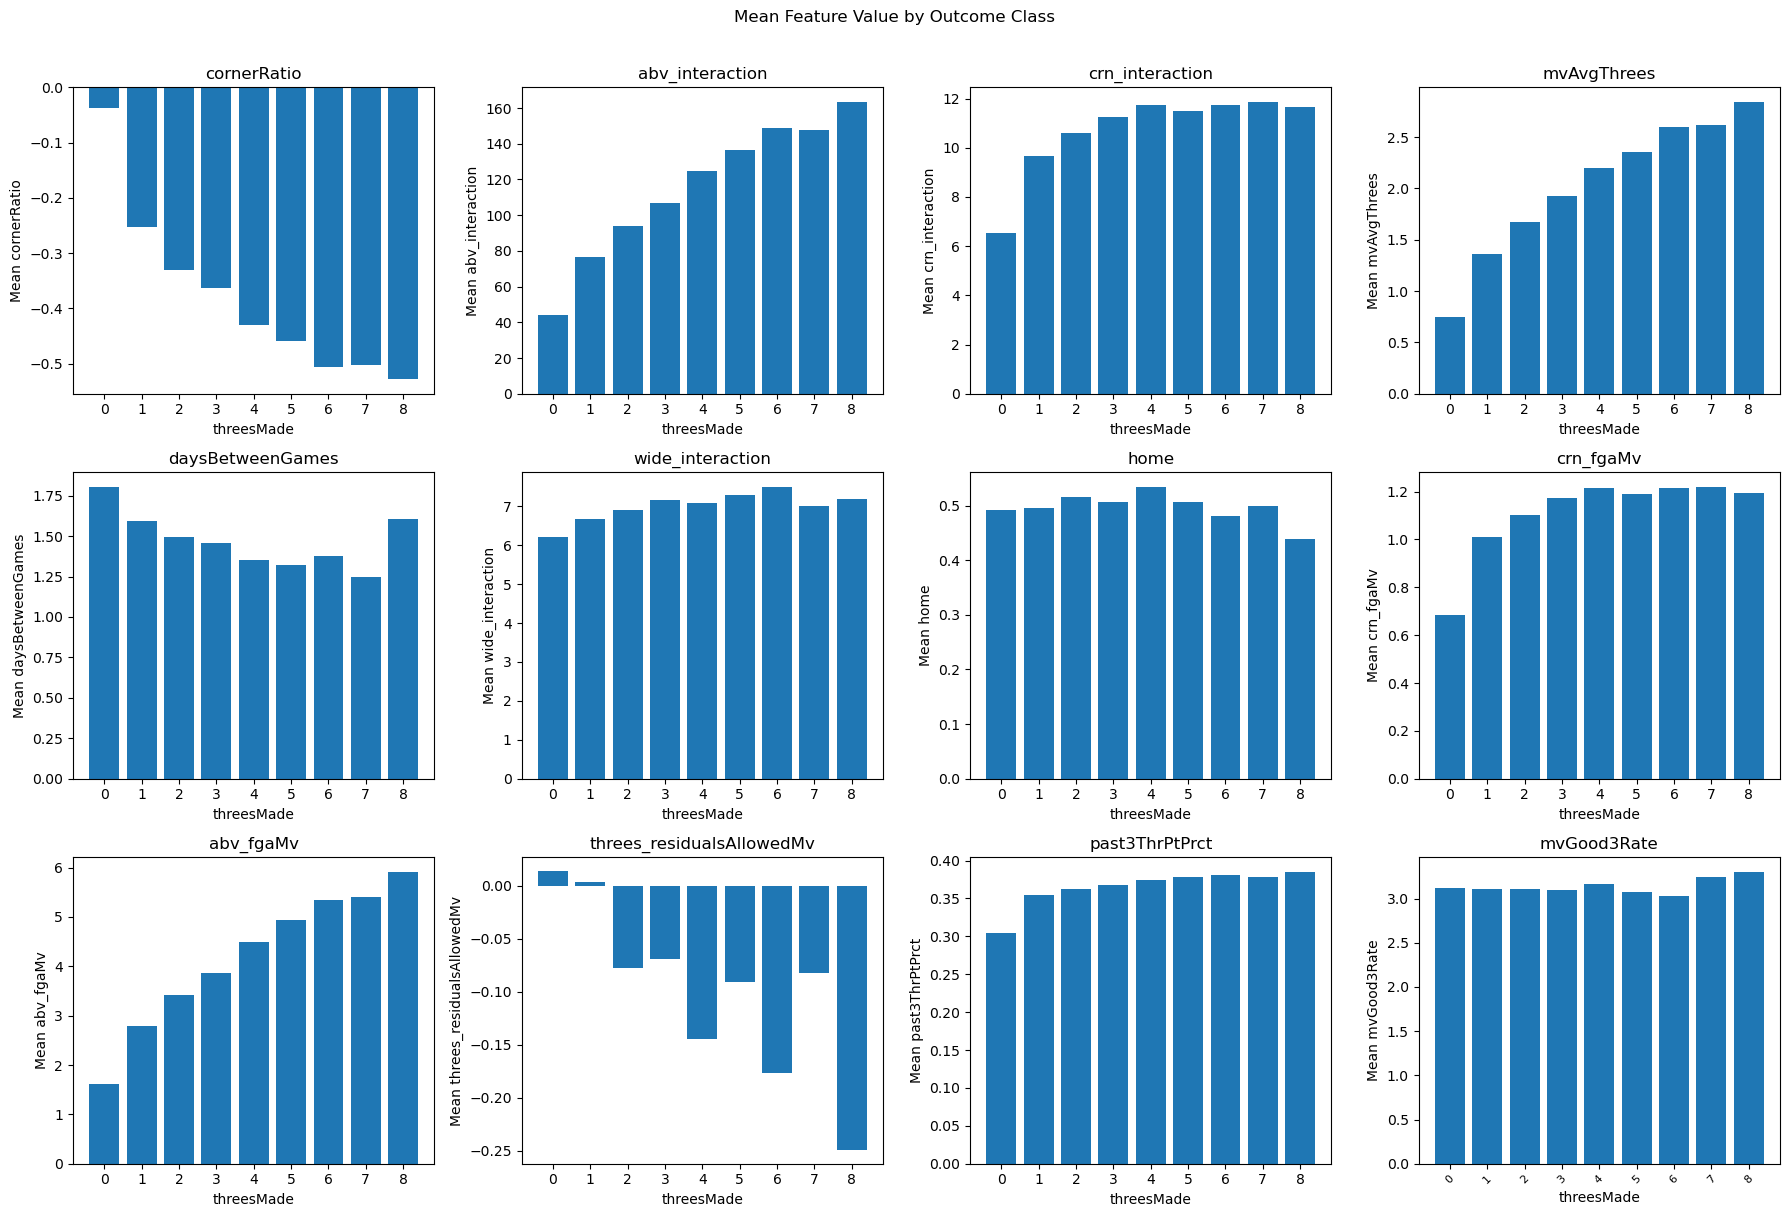

In [43]:
feature_boxplots(test.filter(threes.features[1:]+['threesMade']),threes.features[1:],bin=8)

In [45]:
pd.DataFrame({'actuals': pd.Series(y_test.clip(0,7)).value_counts(normalize=True), 'preds':p.mean()})

,actuals,preds
0,0.399215,0.389843
1,0.245113,0.245630
2,0.164157,0.165519
3,0.096233,0.099857
4,0.052604,0.053811
5,0.025288,0.025560
6,0.010486,0.011659
7,0.006905,0.008119


In [46]:
#checking multi-colinearity between the interaction and the shots
drops = ['crn_fgaMv','abv_fgaMv',]
newCols = [x for x in threes.features if x not in drops] 

In [49]:
multMod = sm.MNLogit(endog = np.array(y_train.clip(0,7)), exog = sm.add_constant(x_train_rescaled.filter(newCols),))
multModFit = multMod.fit(method = 'bfgs',maxiter=1000)
p = multModFit.predict(sm.add_constant(x_test_rescaled.filter(newCols)))

Optimization terminated successfully.
         Current function value: 1.345962
         Iterations: 204
         Function evaluations: 205
         Gradient evaluations: 205


<Axes: >

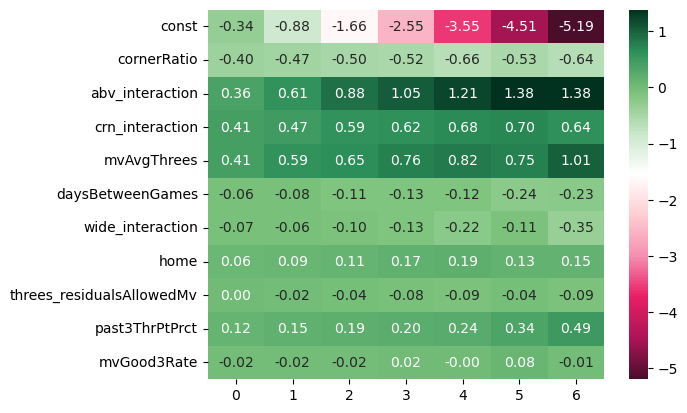

In [50]:
sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

In [51]:
readable_cov(multModFit)[readable_cov(multModFit).parameter.isin(['abv_interaction','crn_interaction'])]

,outcome,parameter,coefficient,std_error,z_score,abs_z
2,1,abv_interaction,-1.658195,0.023734,-69.864550,69.864550
3,1,crn_interaction,-2.554031,0.014041,-181.891734,181.891734
13,2,abv_interaction,-0.638239,0.025857,-24.683709,24.683709
14,2,crn_interaction,0.357186,0.016112,22.169045,22.169045
24,3,abv_interaction,0.620062,0.029349,21.127487,21.127487
25,3,crn_interaction,0.680439,0.019218,35.406550,35.406550
35,4,abv_interaction,-0.060746,0.034760,-1.747590,1.747590
36,4,crn_interaction,-0.081597,0.024022,-3.396760,3.396760
46,5,abv_interaction,-0.219109,0.043419,-5.046412,5.046412
47,5,crn_interaction,-0.106233,0.031765,-3.344374,3.344374


Optimization terminated successfully.
         Current function value: 1.344764
         Iterations: 205
         Function evaluations: 206
         Gradient evaluations: 206
brier score of:  0.655


<Axes: >

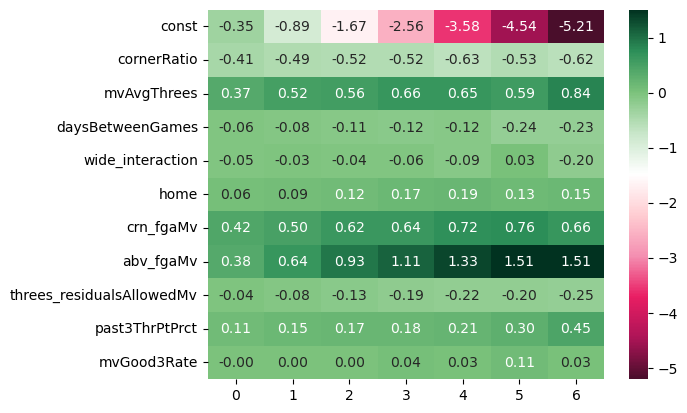

In [54]:
intdrops = ['abv_interaction','crn_interaction',]
newColsInt = [x for x in threes.features if x not in intdrops] 
multMod = sm.MNLogit(endog = np.array(y_train.clip(0,7)), exog = sm.add_constant(x_train_rescaled.filter(newColsInt),))
multModFit = multMod.fit(method = 'bfgs',maxiter=1000)
p = multModFit.predict(sm.add_constant(x_test_rescaled.filter(newColsInt)))
threes.brier_scores(y_test.clip(0,7),p)
sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

In [55]:
threes.brier_scores(y_test.clip(0,7),p)

brier score of:  0.655


np.float64(0.6547085748733338)

<Axes: >

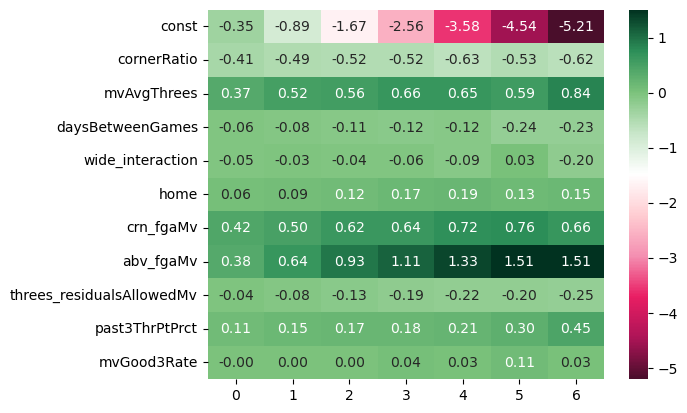

In [58]:
sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)

In [535]:
train.mvGood3Rate.describe()

count    69454.000000
mean         0.894080
std          0.037629
min          0.665306
25%          0.873171
50%          0.897872
75%          0.918798
max          1.098039
Name: mvGood3Rate, dtype: float64

In [536]:
x_train.mvGood3Rate.describe()

count    69454.000000
mean        -1.427623
std          0.024438
min         -1.576197
25%         -1.441203
50%         -1.425161
75%         -1.411571
max         -1.295166
Name: mvGood3Rate, dtype: float64

In [59]:
def mod_run(intdrops):
    
    newColsInt = [x for x in threes.features if x not in intdrops] 
    multMod = sm.MNLogit(endog = np.array(y7cap), exog = sm.add_constant(x_train_rescaled.filter(newColsInt),))
    multModFit = multMod.fit(method = 'bfgs',maxiter=1000)
    p = multModFit.predict(sm.add_constant(x_test_rescaled.filter(newColsInt)))
    print(threes.brier_scores(actualsBin7,p))
    y_test_bin = label_binarize(y_test.clip(upper=7), classes=sorted(y_test.clip(upper=7).unique()))
    model_brier = ((p.values - y_test_bin) ** 2).mean()
    null_brier = ((null_probs - y_test_bin) ** 2).mean()
    skill_score = 1 - (model_brier / null_brier)
    print('Model Brier: {:.4f}'.format(model_brier))
    print('Null Brier: {:.4f}'.format(null_brier))
    print('Skill score: {:.4f}'.format(skill_score))
    sns.heatmap(multModFit.params,annot=True,fmt='.2f',cmap = etl.vlog_r)
    plt.show()

In [76]:
from optbinning import MulticlassOptimalBinning
mcopt =  MulticlassOptimalBinning('cornerRatio',solver='cp')

In [103]:
raw_ratio = train.abv_fgaMv / (train.abv_fgaMv + train.crn_fgaMv)
mcopt.fit(raw_ratio.values,train.threesMade.clip(upper=7).values)

,name,'cornerRatio'
,prebinning_method,'cart'
,solver,'mip'
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,monotonic_trend,'auto'
,min_event_rate_diff,0


In [116]:
mcopt.binning_table.build()

,Bin,Count,Count (%),Event_0,Event_1,Event_2,Event_3,Event_4,Event_5,Event_6,Event_7,Event_rate_0,Event_rate_1,Event_rate_2,Event_rate_3,Event_rate_4,Event_rate_5,Event_rate_6,Event_rate_7
0,"(-inf, 0.51)",9104,0.132940,5628,1991,932,362,142,30,14,5,0.618190,0.218695,0.102373,0.039763,0.015598,0.003295,0.001538,0.000549
1,"[0.51, 0.69)",17661,0.257893,7140,4966,2972,1456,670,286,111,60,0.404281,0.281185,0.168280,0.082442,0.037937,0.016194,0.006285,0.003397
2,"[0.69, 0.72)",3563,0.052028,1292,961,612,386,178,74,38,22,0.362616,0.269717,0.171765,0.108336,0.049958,0.020769,0.010665,0.006175
3,"[0.72, 0.78)",11052,0.161385,3717,2947,1958,1242,636,317,140,95,0.336319,0.266649,0.177163,0.112378,0.057546,0.028683,0.012667,0.008596
4,"[0.78, 0.85)",11009,0.160758,3138,2735,2159,1442,817,426,178,114,0.285040,0.248433,0.196112,0.130984,0.074212,0.038696,0.016169,0.010355
5,"[0.85, inf)",14426,0.210654,5441,2932,2358,1557,983,601,294,260,0.377166,0.203244,0.163455,0.107930,0.068141,0.041661,0.020380,0.018023
6,Special,0,0.000000,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Missing,1667,0.024342,1660,7,0,0,0,0,0,0,0.995801,0.004199,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Totals,,68482,1.000000,28016,16539,10991,6445,3426,1734,775,556,0.409100,0.241509,0.160495,0.094112,0.050028,0.025321,0.011317,0.008119


In [118]:
pd.to_pickle(mcopt,'../nba/data/model/2025-26Run/multiClassOpBin.pkl')

In [105]:
print(mcopt.transform(raw_ratio.values[:5], metric='mean_woe'))
print(mcopt.transform(raw_ratio.values[:5], metric='indices'))

[-0.25832614 -0.25832614 -0.25832614 -0.25832614 -0.25832614]
[5 5 5 5 5]


In [668]:
x_train_rescaled['cornerRatio'] = mcopt.transform(raw_ratio.values, metric='mean_woe')
test_raw_ratio = x_test.abv_fgaMv / (x_test.abv_fgaMv + x_test.crn_fgaMv)
x_test_rescaled['cornerRatio'] = mcopt.transform(test_raw_ratio.values, metric='mean_woe')

In [672]:
y_test.describe()

count    23173.000000
mean         1.314849
std          1.517702
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         12.000000
Name: threesMade, dtype: float64

In [677]:

y_test_bin = label_binarize(y_test.clip(upper=7), classes=sorted(y_test.clip(upper=7).unique()))
model_brier = ((p.values - y_test_bin) ** 2).mean()
null_brier = ((null_probs - y_test_bin) ** 2).mean()
skill_score = 1 - (model_brier / null_brier)
print('Model Brier: {:.4f}'.format(model_brier))
print('Null Brier: {:.4f}'.format(null_brier))
print('Skill score: {:.4f}'.format(skill_score))

Model Brier: 0.0823
Null Brier: 0.0926
Skill score: 0.1117


In [678]:
def player_calibration(df, probs, y, top_n=20):
    point_classes = np.array(probs.columns)
    results = []
    for player, grp in df.groupby('name'):
        idx = grp.index
        pred_mean = probs.loc[idx].mean()
        actual_dist = y.loc[idx].value_counts(normalize=True).reindex(point_classes, fill_value=0)
        brier = ((probs.loc[idx].values - label_binarize(y.loc[idx].clip(upper=7), 
                  classes=sorted(point_classes))) ** 2).mean()
        results.append({
            'player': player,
            'n_games': len(grp),
            'actual_mean': y.loc[idx].mean(),
            'pred_mean': (probs.loc[idx].values * point_classes).sum(axis=1).mean(),
            'overconfidence': (probs.loc[idx].values * point_classes).sum(axis=1).mean() - y.loc[idx].mean(),
            'brier': brier
        })
    df_out = pd.DataFrame(results).sort_values('brier', ascending=False)
    print('Top {} most miscalibrated players:'.format(top_n))
    print(df_out.head(top_n).to_string(index=False))
    return df_out

In [683]:
p.values[0] - y_test_bin[0]

array([ 0.39839598,  0.29267158,  0.1765316 ,  0.07930514,  0.03338215,
       -0.98573177,  0.00361317,  0.00183215])

In [682]:
(p.sub(self.ohe_actuals(actuals)) ** 2).sum(axis=1).mean()

array([0, 0, 0, 0, 0, 1, 0, 0])

Dropping: cornerRatio
Optimization terminated successfully.
         Current function value: 1.359304
         Iterations: 173
         Function evaluations: 174
         Gradient evaluations: 174
brier score of:  0.658
0.6584288961675436


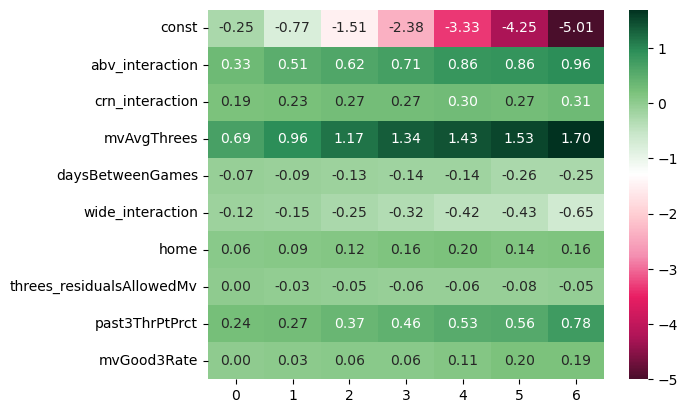

Dropping: abv_interaction
Optimization terminated successfully.
         Current function value: 1.358572
         Iterations: 224
         Function evaluations: 225
         Gradient evaluations: 225
brier score of:  0.660
0.6604157324431498


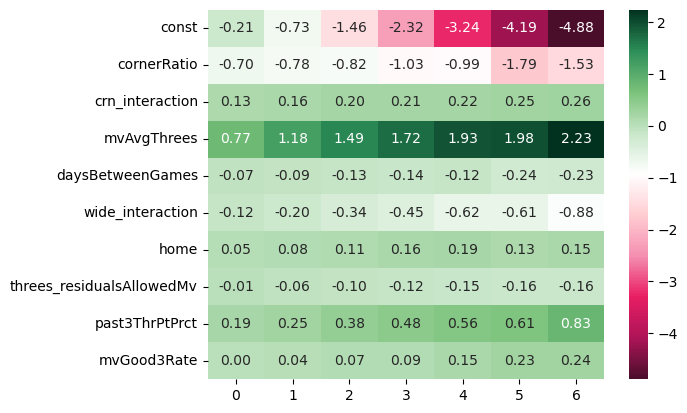

Dropping: crn_interaction
Optimization terminated successfully.
         Current function value: 1.352410
         Iterations: 199
         Function evaluations: 200
         Gradient evaluations: 200
brier score of:  0.658
0.6580636665529733


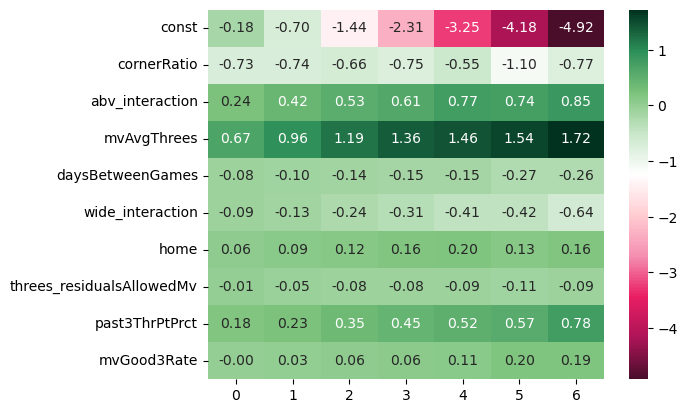

Dropping: mvAvgThrees
Optimization terminated successfully.
         Current function value: 1.374556
         Iterations: 206
         Function evaluations: 207
         Gradient evaluations: 207
brier score of:  0.665
0.6646503713867524


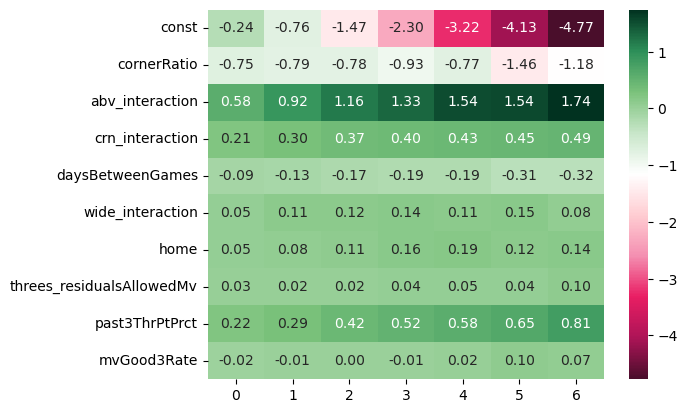

Dropping: daysBetweenGames
Optimization terminated successfully.
         Current function value: 1.351067
         Iterations: 215
         Function evaluations: 216
         Gradient evaluations: 216
brier score of:  0.658
0.6577866317604545


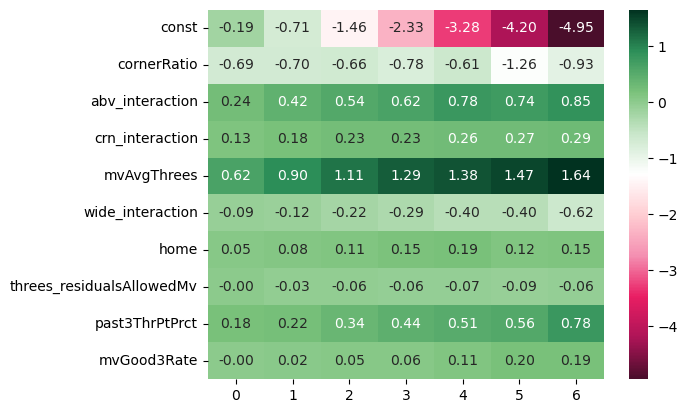

Dropping: wide_interaction
Optimization terminated successfully.
         Current function value: 1.352239
         Iterations: 216
         Function evaluations: 217
         Gradient evaluations: 217
brier score of:  0.658
0.657918435767597


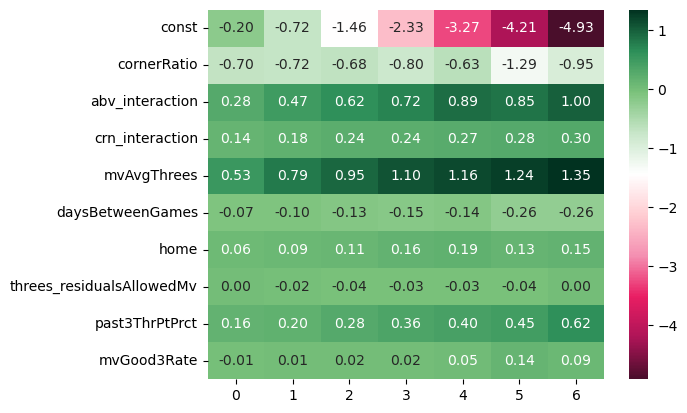

Dropping: home
Optimization terminated successfully.
         Current function value: 1.350286
         Iterations: 197
         Function evaluations: 198
         Gradient evaluations: 198
brier score of:  0.657
0.6572983487652203


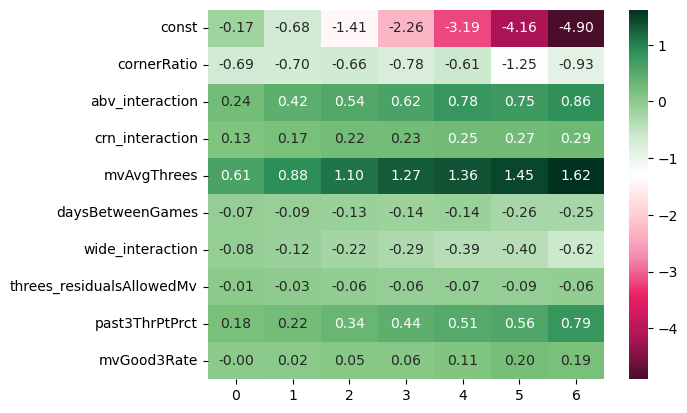

Dropping: crn_fgaMv
Optimization terminated successfully.
         Current function value: 1.350034
         Iterations: 219
         Function evaluations: 220
         Gradient evaluations: 220
brier score of:  0.657
0.6572033984126716


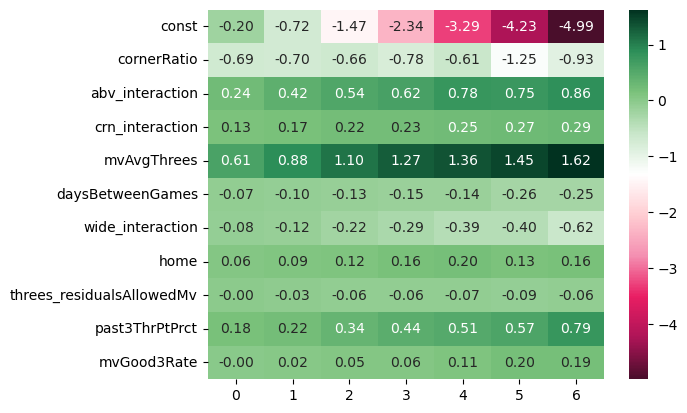

Dropping: abv_fgaMv
Optimization terminated successfully.
         Current function value: 1.350034
         Iterations: 219
         Function evaluations: 220
         Gradient evaluations: 220
brier score of:  0.657
0.6572033984126716


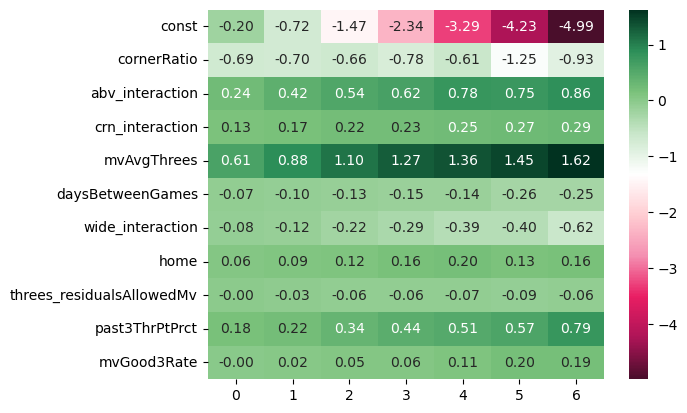

Dropping: threes_residualsAllowedMv
Optimization terminated successfully.
         Current function value: 1.350238
         Iterations: 215
         Function evaluations: 216
         Gradient evaluations: 216
brier score of:  0.657
0.6572152024050106


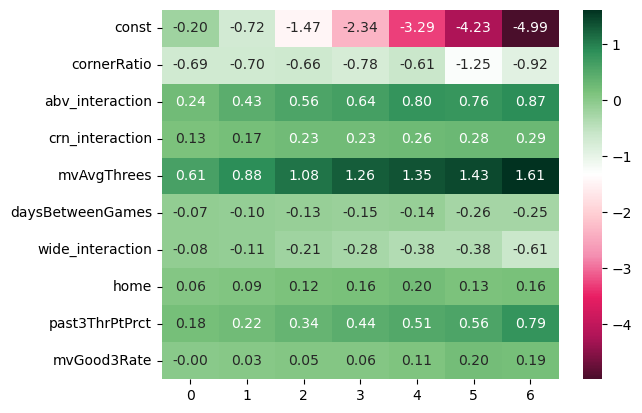

Dropping: past3ThrPtPrct
Optimization terminated successfully.
         Current function value: 1.353479
         Iterations: 205
         Function evaluations: 206
         Gradient evaluations: 206
brier score of:  0.659
0.6589319471170408


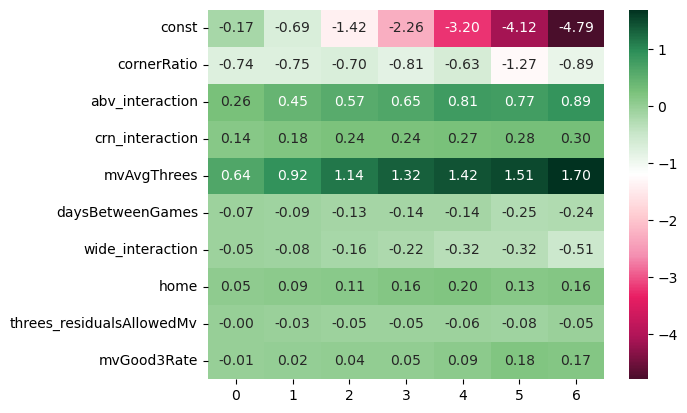

Dropping: mvGood3Rate
Optimization terminated successfully.
         Current function value: 1.350478
         Iterations: 219
         Function evaluations: 220
         Gradient evaluations: 220
brier score of:  0.657
0.6573489753046822


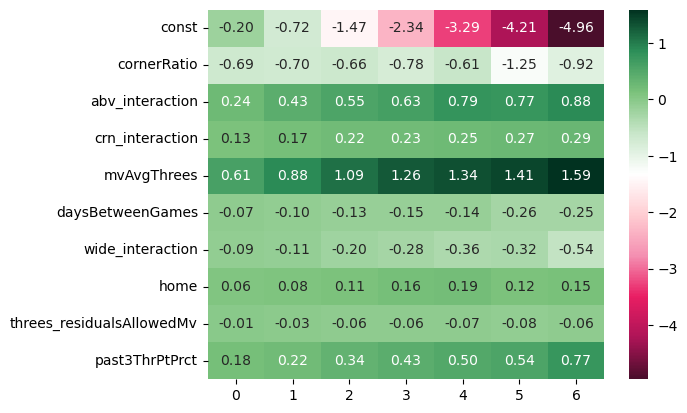

In [693]:
for col in threes.features[1:]:
    print('Dropping:',col)
    mod_run([col,'crn_fgaMv','abv_fgaMv'])
    